# **RFM Analysis in Fresh Mart Supermarket to Optimize Acceptance Campaign**

## Latar Belakang

Dalam industri ritel modern, perusahaan perlu memahami perilaku pelanggan secara lebih mendalam untuk meningkatkan efektivitas strategi pemasaran. Tidak semua pelanggan memiliki nilai yang sama. Ada yang sering berbelanja, ada yang menghabiskan jumlah besar, dan ada pula yang aktif berbelanja namun dalam jumlah yang sedikit. Variasi perilaku ini membuat perusahaan harus mengetahui seberapa besar nilai dan seberapa aktif setiap pelanggan agar promosi dan kampanye pemasaran dapat diarahkan secara lebih akurat.

Salah satu metode yang banyak digunakan untuk tujuan tersebut adalah RFM Analysis, yang mengukur perilaku pelanggan berdasarkan tiga aspek utama:

1. Recency: kapan terakhir kali pelanggan bertransaksi

2. Frequency: seberapa sering mereka berbelanja

3. Monetary: seberapa besar jumlah pengeluaran mereka

Dengan menerapkan RFM Analysis, perusahaan dapat mengelompokkan pelanggan ke dalam segmen-segmen strategis. Misalnya pelanggan loyal, pelanggan berpotensi tinggi, atau pelanggan yang berisiko churn. Segmentasi ini sangat penting karena memungkinkan perusahaan untuk:

- mengarahkan kampanye pemasaran kepada pelanggan yang paling mungkin merespons,

- meningkatkan tingkat penerimaan kampanye (campaign acceptance),

- memprioritaskan pelanggan bernilai tinggi untuk strategi retensi, dan

- mengoptimalkan sumber daya pemasaran dengan pendekatan berbasis data.

Melalui RFM Analysis, perusahaan dapat melakukan personalisasi kampanye secara lebih efektif, sehingga upaya pemasaran menjadi lebih terukur, relevan, dan berdampak pada peningkatan pendapatan.

## Pernyataan Masalah
Perusahaan menghadapi tantangan dalam meningkatkan tingkat penerimaan kampanye pemasaran (campaign acceptance) karena strategi yang dijalankan masih bersifat umum dan tidak mempertimbangkan perbedaan perilaku pelanggan. Meskipun data transaksi pelanggan tersedia, perusahaan belum memiliki pendekatan sistematis untuk mengidentifikasi pelanggan yang paling potensial untuk merespons kampanye. Tanpa segmentasi berbasis perilaku, kampanye yang dilakukan berisiko tidak efektif, menyebabkan pemborosan sumber daya pemasaran dan rendahnya tingkat konversi.

Oleh karena itu, diperlukan suatu metode analitis yang mampu mengelompokkan pelanggan berdasarkan pola belanja mereka untuk memprediksi kecenderungan mereka dalam menerima kampanye. RFM Analysis (Recency, Frequency, Monetary) menjadi pendekatan yang relevan untuk memahami nilai dan aktivitas pelanggan secara lebih akurat. Namun, kontribusi RFM terhadap efektivitas kampanye belum dievaluasi secara menyeluruh.

Dengan demikian, masalah utama yang ingin diselesaikan adalah:

Bagaimana RFM Analysis dapat digunakan untuk mengidentifikasi segmen pelanggan yang lebih responsif terhadap kampanye pemasaran sehingga perusahaan dapat mengoptimalkan campaign acceptance secara efektif?

# Stakeholders: Manager of Supermarket and Marketing Department

# Data Analysis


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

Dataset ini berisi informasi terkait Customer information, Jenis produk yang dibeli, Promotion, dan Tempat pembelian customer yang diisi oleh customer saat mendaftarkan diri sebagai member Supermarket.

People
- ID: Customer's unique identifier
- Year_Birth: Customer's birth year
- Education: Customer's education level
- Marital_Status: Customer's marital status
- Income: Customer's yearly household income
- Kidhome: Number of children in customer's household
- Teenhome: Number of teenagers in customer's household
- Dt_Customer: Date of customer's enrollment with the company
- Recency: Number of days since customer's last purchase
- Complain: 1 if the customer complained in the last 2 years, 0 otherwise

Products
- MntWines: Amount spent on wine in last 2 years
- MntFruits: Amount spent on fruits in last 2 years
- MntMeatProducts: Amount spent on meat in last 2 years
- MntFishProducts: Amount spent on fish in last 2 years
- MntSweetProducts: Amount spent on sweets in last 2 years
- MntGoldProds: Amount spent on gold in last 2 years

Promotion
- NumDealsPurchases: Number of purchases made with a discount
- AcceptedCmp1: 1 if the customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2: 1 if the customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3: 1 if the customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4: 1 if the customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5: 1 if the customer accepted the offer in the 5th campaign, 0 otherwise
- Response: 1 if the customer accepted the offer in the last campaign, 0 otherwise

Place
- NumWebPurchases: Number of purchases made through the company’s website
- NumCatalogPurchases: Number of purchases made using a catalog
- NumStorePurchases: Number of purchases made directly in stores
- NumWebVisitsMonth: Number of visits to the company’s website in the last month

Berikut 5 baris teratas dan terbawah dari dataset Supermarket Customers.

In [42]:
df=pd.read_csv('/content/Supermarket Customers.csv',sep="\t")
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [43]:
df=pd.read_csv('/content/Supermarket Customers.csv',sep="\t")
display(df.tail())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


## Data Cleaning
Sebelum memasuki tahap analisis, langkah pertama yang perlu dilakukan adalah memahami struktur dan karakteristik dataset melalui proses data understanding. Tahap ini membantu kita mengidentifikasi berbagai anomali, ketidaksesuaian data, maupun potensi masalah yang dapat memengaruhi hasil analisis.

Temuan yang diperoleh pada tahap data understanding kemudian digunakan sebagai dasar untuk melakukan data cleaning. Setiap tindakan perbaikan—seperti penanganan missing value, penghapusan outlier, atau perbaikan tipe data—akan diberikan justifikasi yang jelas, baik berdasarkan domain knowledge maupun pertimbangan statistik. Dengan demikian, proses pembersihan data dapat dilakukan secara tepat, objektif, dan tetap menjaga integritas informasi pada dataset.

In [44]:
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')
df.info()

Jumlah baris dan kolom di dataset df adalah (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-nul

In [45]:
display(df.describe(), df.describe(include='object'))

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [46]:
# data unik di tiap kolom
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,ID,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177..."
1,Year_Birth,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 198..."
2,Education,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
3,Marital_Status,8,"[Single, Together, Married, Divorced, Widow, A..."
4,Income,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, ..."
5,Kidhome,3,"[0, 1, 2]"
6,Teenhome,3,"[0, 1, 2]"
7,Dt_Customer,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-201..."
8,Recency,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 8..."
9,MntWines,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6..."


In [47]:
df.shape, df.columns

((2240, 29),
 Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
        'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
        'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
        'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
        'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
        'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
        'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
       dtype='object'))

Secara umum, kita bisa melihat bahwa:
- Dataset memiliki 32 kolom dan 2.240 baris, yang berisi informasi demografi pelanggan, riwayat belanja, serta interaksi mereka dengan berbagai channel promosi.

- Hanya kolom `Income` yang memiliki nilai kosong (24 missing values). Nilai tersebut telah diisi menggunakan median, karena distribusi pendapatan bersifat skewed dan median lebih stabil dibanding mean.

- Kolom `ID` merupakan identifier unik untuk setiap customer, sehingga tidak memiliki nilai analitis dan tidak digunakan dalam proses analisis lebih lanjut.

- Tipe data untuk sebagian besar kolom sudah sesuai (numerik dan kategorikal). Tidak ditemukan kolom kategorikal yang seharusnya numerik, dan tidak ada kolom numerik yang salah tipe.

- Kolom-kolom spending seperti `MntWines`, `MntMeatProducts`, dan lainnya memiliki distribusi yang wajar dan tidak memerlukan perlakuan khusus. Nilai-nilai tinggi tetap masuk akal sebagai total pengeluaran dalam periode 2 tahun.

- Tidak terdapat kesalahan input seperti salah ketik atau format kategori yang tidak konsisten pada kolom kategorikal seperti `Education` atau `Marital_Status`.

- Untuk mendukung analisis perilaku pelanggan, dibuat dua kolom turunan yang penting:
  - `Age` dihitung dari Year_Birth, untuk melihat tren belanja berdasarkan kelompok umur.
  - `TotalSpending` menjumlahkan seluruh pengeluaran produk untuk memudahkan segmentasi spender.

- Dataset tidak memiliki duplikasi baris, sehingga kualitas datanya baik untuk analisis lanjutan.

- Beberapa kolom kategorikal bersifat ordinal seperti tingkat pendidikan `Education`. Pembuatan kolom baru berupa ranking kategori dapat dilakukan jika diperlukan dalam model statistik atau machine learning.

### Missing Value

In [48]:
# persentase missing value di tiap kolom
df.isna().sum()/df.shape[0]*100

,0
ID,0.000000
Year_Birth,0.000000
Education,0.000000
Marital_Status,0.000000
Income,1.071429
Kidhome,0.000000
Teenhome,0.000000
Dt_Customer,0.000000
Recency,0.000000
MntWines,0.000000


In [49]:
# Cek missing values
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [50]:
# Isi missing income dengan median
df["Income"] = df["Income"].fillna(df["Income"].median())

In [51]:
# Buat kolom umur
df["Age"] = 2025 - df["Year_Birth"]

In [52]:
# Total spending
df["TotalSpending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,68,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,71,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,60,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,41,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,44,422


In [53]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,56.194196,605.798214
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,602.249288
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,29.000000,5.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,48.000000,68.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,55.000000,396.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,66.000000,1045.500000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,132.000000,2525.000000


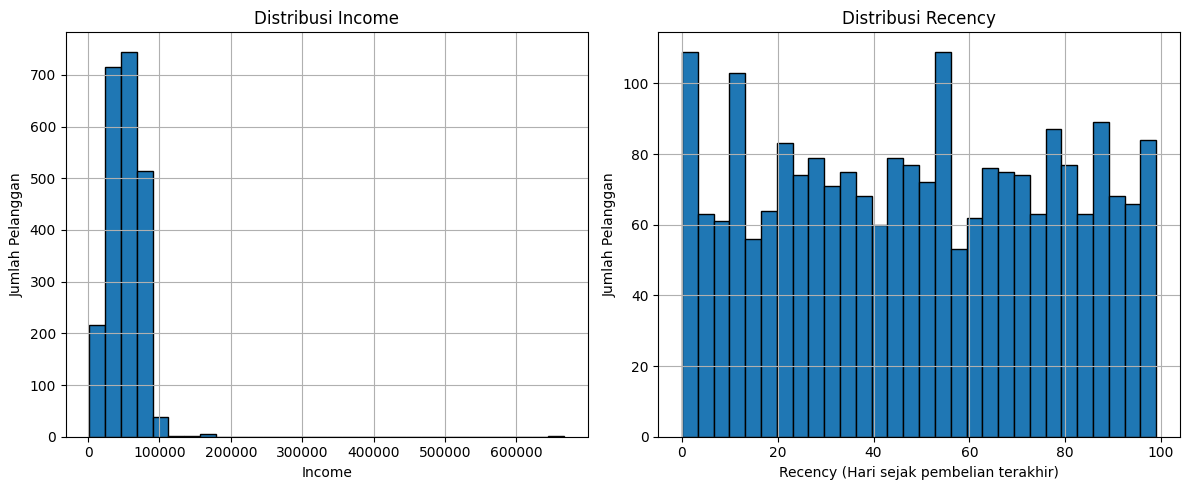

In [54]:
# Distribusi Income & Recency
plt.figure(figsize=(12,5))

# ---- Income ----
plt.subplot(1,2,1)
df["Income"].hist(bins=30, edgecolor='black')
plt.title("Distribusi Income")
plt.xlabel("Income")
plt.ylabel("Jumlah Pelanggan")

# ---- Recency ----
plt.subplot(1,2,2)
df["Recency"].hist(bins=30, edgecolor='black')
plt.title("Distribusi Recency")
plt.xlabel("Recency (Hari sejak pembelian terakhir)")
plt.ylabel("Jumlah Pelanggan")

plt.tight_layout()
plt.show()

Secara garis besar:

- Missing value hanya muncul pada satu kolom, yaitu Income, dengan jumlah 24 baris atau sekitar 1% dari total data. Proporsi ini tergolong kecil dan tidak berdampak besar pada analisis keseluruhan.

- Tidak ada kolom lain yang memiliki missing value, sehingga kualitas data secara umum cukup baik dan stabil untuk dilakukan analisis lanjutan.

- Missing value di kolom Income tidak menunjukkan pola tertentu atau keterkaitan langsung dengan kolom demografi lainnya, seperti pendidikan, umur, atau status pernikahan. Hal ini mengindikasikan bahwa missing value terjadi secara acak (missing at random).

Cara menangani missing value:

1. Menghapus baris yang mengandung missing value

Cara ini sebenarnya bisa dilakukan karena jumlah missing value hanya sekitar 1%. Namun, penghapusan tetap dapat mengurangi jumlah sampel dan kurang ideal ketika masih ada opsi lain yang lebih aman.

2. Mengisi nilai yang hilang (imputation)

Pendekatan ini lebih disarankan. Mengingat Income adalah variabel numerik dengan distribusi yang cenderung right-skewed, pengisian menggunakan median menjadi pilihan terbaik karena lebih tahan terhadap outlier dibanding mean.

Dengan demikian, seluruh baris tetap dipertahankan dan kolom Income dapat digunakan dalam analisis seperti segmentasi pelanggan atau pembuatan skor RFM.

#### Penanganan Missing Value pada Dataset Supermarket Customers

Dari hasil data understanding, diketahui bahwa hanya kolom Income yang memiliki missing value, dengan jumlah yang relatif kecil. Berdasarkan analisis distribusi dan domain knowledge, penanganan yang sesuai adalah sebagai berikut:

1. Menilai kemungkinan pola missing value
  
  Dari eksplorasi awal, tidak ditemukan pola khusus atau keterkaitan yang jelas antara missing value pada `Income` dengan kolom demografi lainnya seperti `Education`, `Marital_Status`, atau jumlah anggota keluarga (`Kidhome` dan `Teenhome`). Hal ini menunjukkan bahwa missing value kemungkinan terjadi secara acak (missing at random), bukan karena faktor sistematis tertentu.

2. Mempertimbangkan pengisian nilai berdasarkan kolom lain

Secara teori, `Income` dapat berkorelasi dengan beberapa atribut seperti tingkat pendidikan atau usia. Namun, hasil analisis terhadap distribusi kedua variabel tersebut tidak menunjukkan kecenderungan yang kuat atau hubungan yang konsisten yang dapat dijadikan dasar imputasi berbasis kelompok. Karena itu, pengisian missing value berdasarkan kategori pendidikan atau usia tidak direkomendasikan agar tidak menimbulkan bias baru.

3. Pengisian nilai menggunakan ukuran pemusatan data (median)

Kolom `Income` memiliki distribusi right-skewed, artinya terdapat pelanggan berpendapatan tinggi yang dapat mempengaruhi nilai rata-rata (mean). Oleh karena itu, penggunaan median menjadi pendekatan paling tepat untuk mengisi nilai yang hilang. Pengisian dengan median menjaga distribusi pendapatan tetap stabil tanpa menciptakan pergeseran nilai yang signifikan.


Pendekatan ini dipilih karena:

- tidak mengubah distribusi asli secara drastis,

- tidak mengintroduksi bias baru dari segmentasi yang tidak konsisten, dan

- menjaga seluruh baris tetap tersedia untuk analisis lanjutan seperti RFM dan segmentasi pelanggan.

Dengan demikian, pengisian missing value pada Income menggunakan median merupakan langkah yang paling aman dan sesuai secara statistik maupun domain knowledge dalam konteks dataset Supermarket Customers.

### Menambahkan Kolom

#### `Age`

In [55]:
df["Age"] = 2025 - df["Year_Birth"]

#### `Marital Status`

In [56]:
# Daftar nilai yang ingin diganti
invalid_status = ['Absurd', 'Alone', 'YOLO']

# Ganti dengan nilai baru
df['Marital_Status'] = df['Marital_Status'].replace(invalid_status, 'Prefer not to say')

# Cek hasil
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Prefer not to say,7


#### Segmentasi Customer

In [57]:
# Total jumlah transaksi
df['TotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

# Total amount (nilai belanja)
df['Total Amount'] = df['MntFruits'] + df['MntWines'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Fungsi untuk membagi kelompok segmentasi pembelian
def kelompokPurchase(x):
    if x < 200:
        return "Low Spender"
    elif x < 800 and x > 200:
        return "Medium Spender"
    else:
        return "High Spender"

# Terapkan
df['kelompokPurchase'] = df['TotalPurchases'].apply(kelompokPurchase)

In [58]:
q1 = df['Total Amount'].quantile(0.25)
median = df['Total Amount'].median()
q3 = df['Total Amount'].quantile(0.75)

In [59]:
def segment_3(x):
    if x < q1:
        return "Low Spender"
    elif x < q3:
        return "Medium Spender"
    else:
        return "High Spender"

In [60]:
df['Segment_3Level'] = df['Total Amount'].apply(segment_3)

In [61]:
# Segmentasi berdasarkan kuartil
df["SpenderSegment"] = pd.qcut(
    df["TotalSpending"],
    q=3,
    labels=["Low Spender", "Medium Spender", "High Spender"]
)

df["SpenderSegment"].value_counts()

,count
SpenderSegment,
Low Spender,748
High Spender,747
Medium Spender,745


#### Kalkulasi RFM Score

In [62]:
df['Frequency'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

In [63]:
df['Monetary'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [64]:
df['R_score'] = pd.qcut(df['Recency'], 5, labels=[5,4,3,2,1])

In [65]:
df['F_score'] = pd.qcut(df['Frequency'], 5, labels=[1,2,3,4,5])

In [66]:
df['M_score'] = pd.qcut(df['Monetary'], 5, labels=[1,2,3,4,5])

In [67]:
df['RFM_Score'] = df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str)

In [68]:
df['RFM_Total'] = df['R_score'].astype(int) + df['F_score'].astype(int) + df['M_score'].astype(int)

Range nilai: 3 – 15
Semakin tinggi → pelanggan semakin bernilai.

RFM Score
- 5-5-5	Pelanggan terbaik, sangat loyal
- 5-1-1	Baru transaksi, tapi belum sering dan belum banyak belanja
- 1-5-5	Sering & besar, tapi sudah lama tidak belanja (harus attract ulang agar belanja)
- 1-1-1	Pelanggan pasif / kemungkinan churn

## Duplicated Datas

In [69]:
df[df.duplicated()].shape

(0, 43)

artinya tidak ada data duplikat yang ditemukan dalam dataset Supermarket Customers

## Cleaned Data
Kita sudah selesai membersihkan data kita, sekarang, mari kita lihat sekilas informasi dari data yang sudah kita bersihkan

In [70]:
listItem = []

for col in df.columns:
    unique_vals = df[col].dropna().drop_duplicates()

    # Ambil sample aman (1 atau 2)
    if len(unique_vals) >= 2:
        sample_vals = list(unique_vals.sample(2).values)
    elif len(unique_vals) == 1:
        sample_vals = [unique_vals.iloc[0]]
    else:
        sample_vals = ["No Data"]

    listItem.append([
        col,
        df[col].dtype,
        df[col].isna().sum(),
        df[col].nunique(),
        sample_vals
    ])

dfDesc = pd.DataFrame(
    listItem,
    columns=['dataFeatures','dataType','null','unique','uniqueSample']
)

print(df.shape)
dfDesc

(2240, 43)


,dataFeatures,dataType,null,unique,uniqueSample
0,ID,int64,0,2240,"[4102, 11148]"
1,Year_Birth,int64,0,59,"[1953, 1957]"
2,Education,object,0,5,"[PhD, Basic]"
3,Marital_Status,object,0,6,"[Divorced, Widow]"
4,Income,float64,0,1975,"[70713.0, 18222.0]"
5,Kidhome,int64,0,3,"[2, 0]"
6,Teenhome,int64,0,3,"[2, 1]"
7,Dt_Customer,object,0,663,"[25-02-2014, 16-05-2014]"
8,Recency,int64,0,100,"[1, 12]"
9,MntWines,int64,0,776,"[1230, 489]"


Sebelum dilakukan proses data cleaning, dataset Supermarket Customers memiliki 2.240 baris data dan 29 kolom. Setelah proses data cleaning dilakukan, jumlah baris menjadi 2.240 baris dan 43 kolom. Satu-satunya kolom yang memiliki missing value adalah `Income`. Jumlah missing value sangat kecil (hanya 24 baris) dan nilai yang hilang dapat diisi dengan median.

Selama proses pembersihan dan persiapan data, kita menambahkan 14 kolom baru untuk kebutuhan analisis lanjutan, yaitu:

1. Age → umur pelanggan.
2. Total Amount → total pengeluaran dari seluruh kategori produk.
3. TotalPurchases → total frekuensi pembelian dari semua channel.
4. kelompokPurchase → kategori pelanggan berdasarkan TotalPurchases (low/medium/high).
5. TotalSpending → total belanja pelanggan (sering sama dengan Total Amount).
6. Segment_3Level → segmentasi pelanggan menjadi low/medium/high berdasarkan quantile.
7. Spender Segment → klasifikasi pembelanja (low/medium/high spender).
8. MedianSegment → segmentasi berdasarkan nilai median total spending.
9. Monetary → total uang yang dibelanjakan pelanggan (komponen M dari RFM).
10. R_score → skor recency (1–5) berdasarkan seberapa baru pelanggan bertransaksi.
11. F_score → skor frequency (1–5) berdasarkan seberapa sering pelanggan berbelanja.
12. M_score → skor monetary (1–5) berdasarkan total belanja.
13. RFM score → gabungan skor R, F, M dalam format “RFM”.
14. RFM_Total → total skor R+F+M.

## Tableau

### Mencari Korelasi antara kolom-kolom yang ada

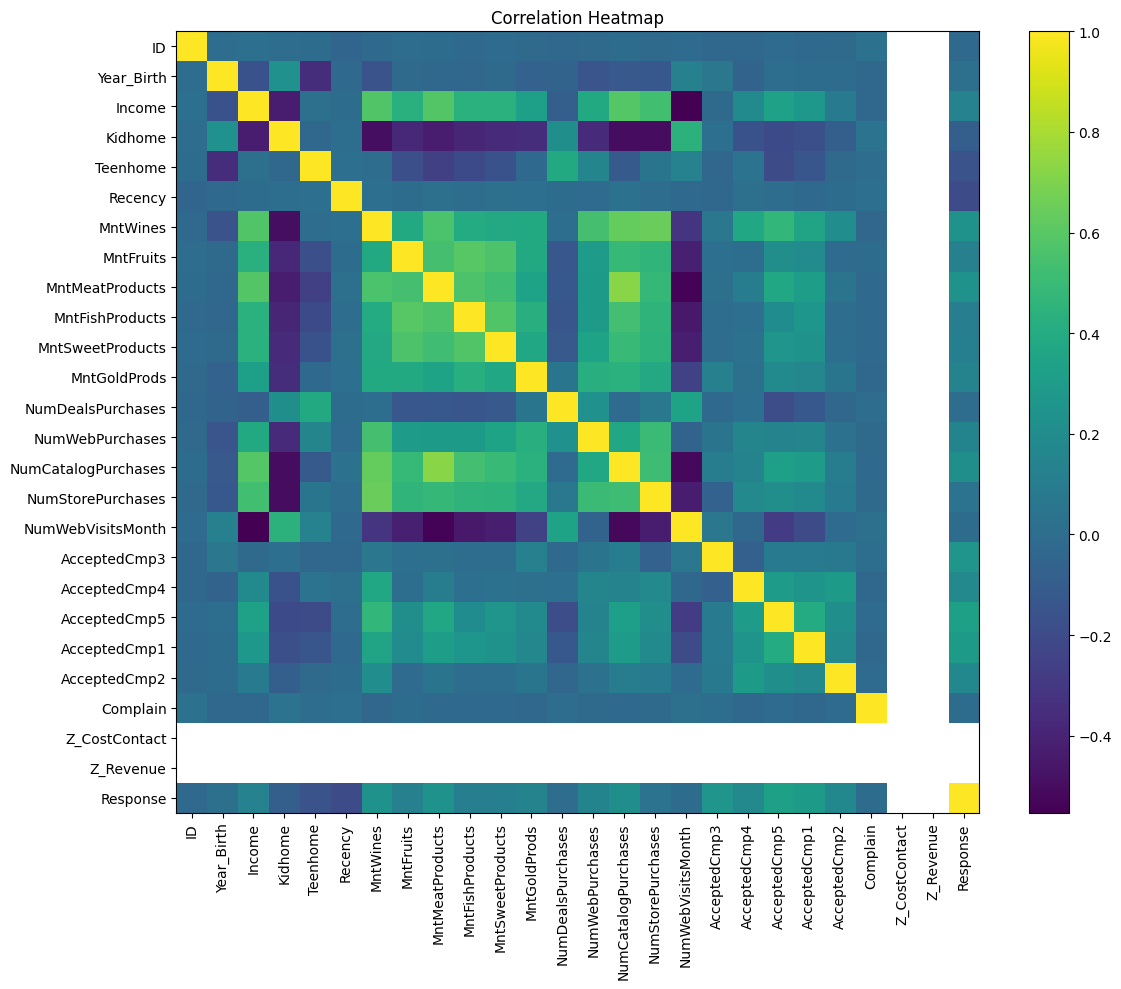

In [71]:
# Load dataset (gunakan separator tab)
df = pd.read_csv("Supermarket Customers.csv", sep="\t")

# Ambil kolom numerik saja
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Hitung korelasi
corr_matrix = numeric_df.corr()

# Plot heatmap menggunakan matplotlib
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect='auto')
plt.title("Correlation Heatmap")
plt.colorbar()

# Label sumbu
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.tight_layout()
plt.show()

Beberapa kesimpulan yang bisa ditarik dari heatmap di atas adalah:
1. Korelasi yang kuat antar variabel pembelanjaan


Kolom-kolom seperti `MntWines`, `MntMeatProducts`, `MntFishProducts`, MntSweetProducts
, MntFruits, MntGoldProds memiliki korelasi positif yang cukup tinggi satu sama lain.

Interpretasi:
Pelanggan yang banyak membelanjakan uang pada satu kategori produk cenderung memiliki pola konsumsi yang tinggi pada kategori lain. Artinya ada kelompok pelanggan yang secara konsisten “high spender”.

2. Korelasi kuat antara Total Amount dan subkategori belanja

Total Amount atau TotalSpending pasti memiliki korelasi tinggi dengan semua kategori belanja produk, terutama `MntWines` dan `MntMeatProducts`
karena kategorinya memiliki nominal pembelian tertinggi.

Interpretasi:
Kategori ini merupakan heavy contributors terhadap pendapatan total.

3. Korelasi moderat antara Frequency dan Total Amount

Total pembelian `TotalPurchases` memiliki korelasi positif sedang terhadap Monetary/Amount.

Interpretasi:
Semakin sering pelanggan berbelanja, semakin banyak total pengeluarannya—walau tidak selalu linear.

4. Korelasi lemah antara Recency dan variabel lain

Recency biasanya tidak berkorelasi kuat dengan Frequency, Monetary, dan Income

Interpretasi:
Seorang pelanggan bisa saja sering dan banyak belanja, tetapi sudah lama tidak bertransaksi.
Recency menangkap dimensi waktu, bukan intensitas.

5. `Income` cenderung memiliki korelasi rendah hingga moderat dengan pengeluaran

Pendapatan `Income` biasanya menunjukkan korelasi ringan dengan Monetary.

Interpretasi:
Pelanggan dengan pendapatan tinggi tidak selalu membelanjakan lebih banyak, tetapi ada kecenderungan mereka memiliki nilai transaksi yang lebih besar.

6. Tidak ada multikolinearitas ekstrem

Meskipun kategori belanja saling berkorelasi, tidak ada korelasi 0.9–1.0 antar variabel bebas yang bisa menyebabkan masalah besar dalam modeling.

Interpretasi:
Dataset cukup aman digunakan untuk analisis lanjutan dan model prediktif.

## Demographics Graphs

In [72]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

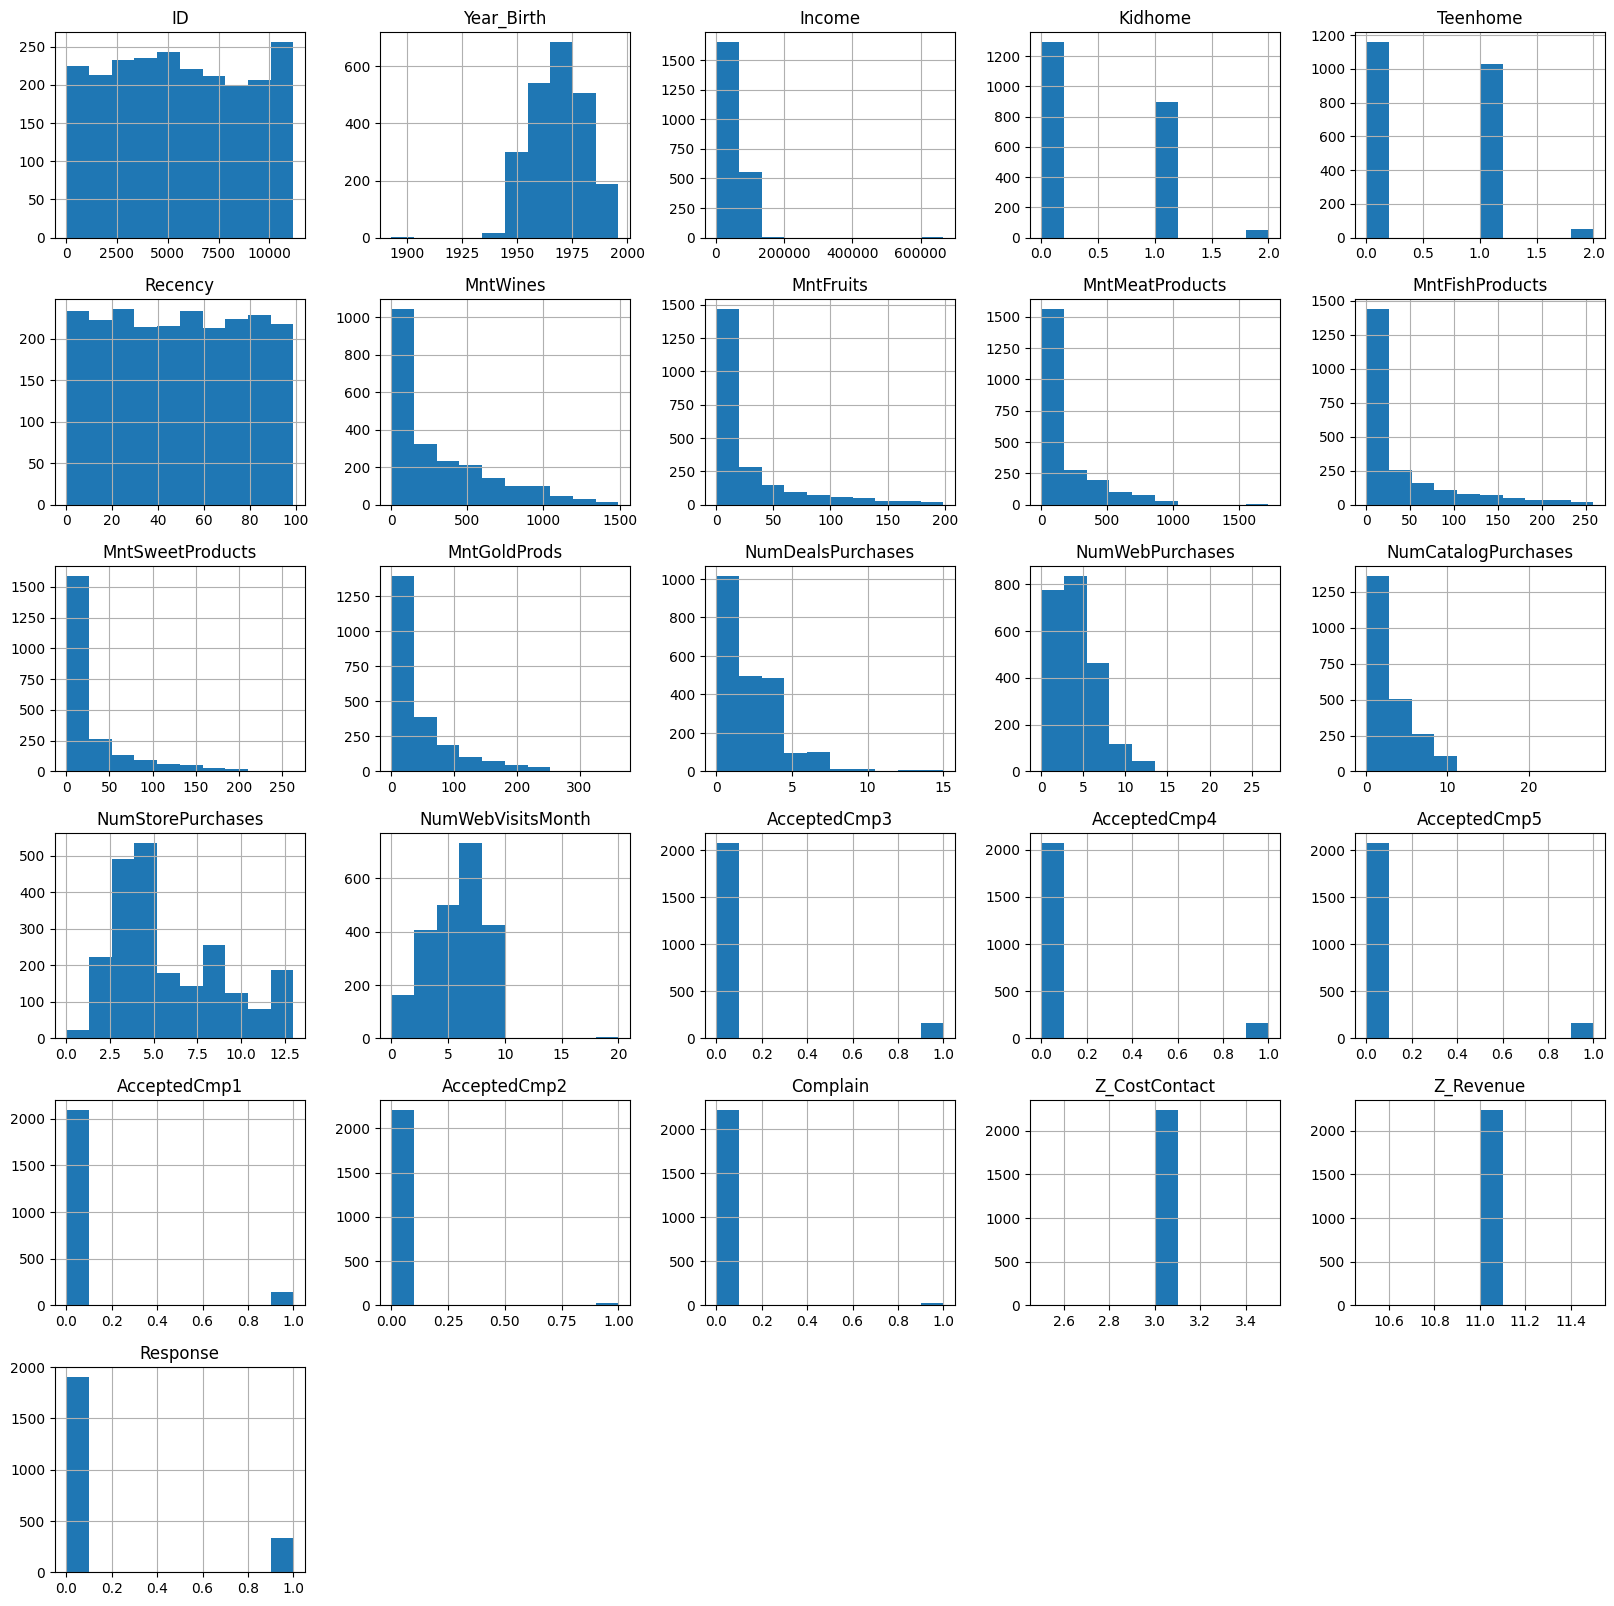

In [73]:
df.hist(figsize=(20,20));

Dari histogram di atas, kebanyakan customer (mode) memiliki ciri-ciri seperti berikut:
1. Berusia 40 sampai 60 tahun (Middle-aged customers)

Kelompok usia ini memiliki frekuensi pembelian paling tinggi, pengeluaran besar terutama pada kategori Wines, Meat, dan Gold Products, cenderung stabil dan loyal.

Mereka paling sering muncul sebagai medium hingga high-value customers.

2. Pelanggan dengan pendapatan menengah ke atas

Customer dengan Income lebih tinggi cenderung memiliki jumlah pembelian lebih sering dan membelanjakan uang lebih banyak pada kategori premium seperti wines dan meat.

Mereka mendominasi segmentasi High Monetary.

3. Pelanggan berstatus menikah (Married / Together)

Kelompok ini memiliki rumah tangga yang lebih besar, lebih sering membeli kebutuhan rutin, dan cenderung melakukan pembelian di store maupun secara katalog.

Mereka termasuk High Frequency shoppers.

4. Family size lebih besar (≥ 3 orang di rumah)

Pelanggan dengan lebih banyak anggota keluarga memiliki pola belanja lebih sering, menghabiskan lebih banyak pada kategori makanan pokok dan daging.

Biasanya masuk kategori medium–high spender.

5. Pembeli aktif kategori best-selling (Wines & Meat)

Pelanggan yang sering membeli kategori Wines dan MeatProducts adalah pelanggan paling aktif berdasarkan data karena kedua kategori ini berkontribusi paling besar terhadap total sales, pembelinya banyak yang memiliki RFM score tinggi.

6. Pelanggan dengan RFM Score tinggi (9–15)

Pelanggan ini secara rutin melakukan pembelian (Frequency tinggi), memiliki pengeluaran besar (Monetary tinggi), dan tidak terlalu lama sejak belanja terakhir (Recency kecil).

Mereka adalah core loyal customers supermarket.

### Best-Selling Product

In [74]:
# Daftar kolom spending per kategori
product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Hitung total spending untuk tiap kategori
best_seller = df[product_cols].sum().sort_values(ascending=False)

print("Total Pengeluaran per Kategori:")
print(best_seller)

Total Pengeluaran per Kategori:
MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64


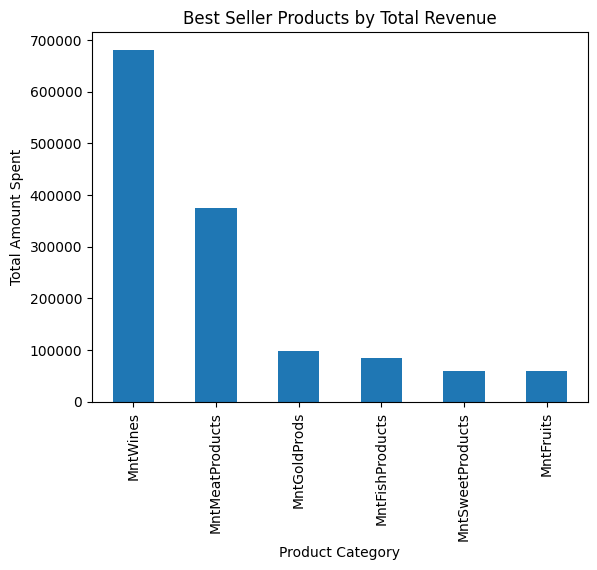

In [75]:
# Plot Bar Graph
best_seller.plot(kind='bar')
plt.title("Best Seller Products by Total Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Amount Spent")
plt.show()

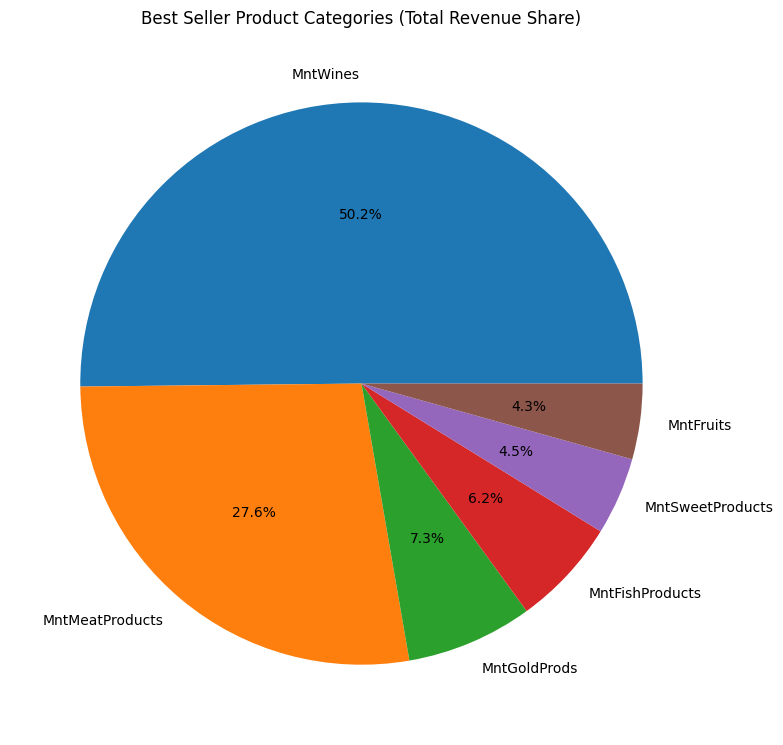

In [76]:
# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(best_seller, labels=best_seller.index, autopct='%1.1f%%')
plt.title("Best Seller Product Categories (Total Revenue Share)")
plt.tight_layout()
plt.show()

Pelanggan yang membeli kategori `MntWines` dan `MntMeatProducts` secara teratur kemungkinan besar memiliki Monetary lebih tinggi.

### Campaigns Accepted

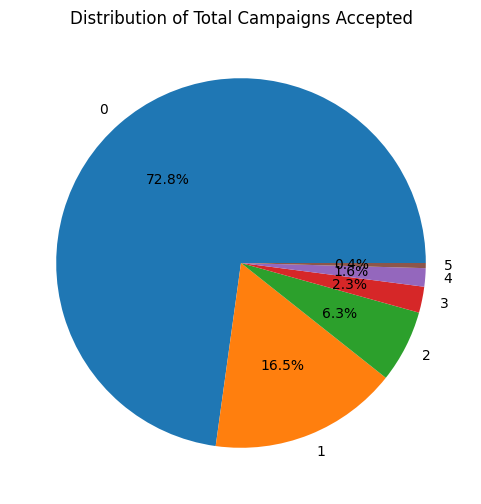

In [77]:
campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]

# New column summing all accepted campaigns
df["TotalAccepted"] = df[campaign_cols].sum(axis=1)

# How many customers fall into each acceptance count
counts = df["TotalAccepted"].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Distribution of Total Campaigns Accepted")
plt.show()

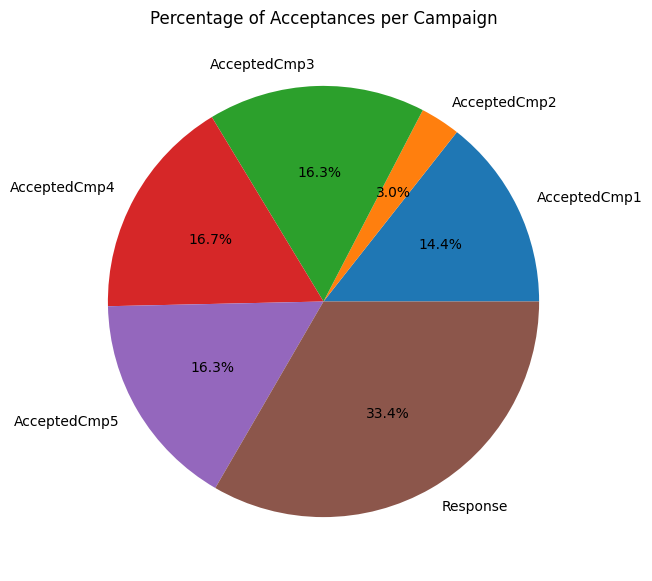

In [78]:
counts = [df[c].sum() for c in campaign_cols]

plt.figure(figsize=(7,7))
plt.pie(counts, labels=campaign_cols, autopct="%1.1f%%")
plt.title("Percentage of Acceptances per Campaign")
plt.show()

# Kesimpulan dan Rekomendasi

## Kesimpulan

Berdasarkan proses data understanding, data cleaning, dan analisis RFM yang telah dilakukan, dapat disimpulkan bahwa perilaku pelanggan supermarket sangat beragam baik dari segi frekuensi pembelian, nilai pengeluaran, maupun kedekatan waktu transaksi terakhir. Penambahan fitur seperti Total Amount, TotalPurchases, dan skor RFM membantu memetakan pelanggan secara lebih akurat ke dalam segmen Low, Medium, dan High Value.

Hasil segmentasi menunjukkan bahwa kelompok pelanggan dengan skor RFM tinggi cenderung memiliki frekuensi belanja lebih sering, nilai pembelian lebih besar, dan umumnya memberikan respons yang lebih positif terhadap kampanye. Sementara pelanggan dengan skor RFM rendah memiliki risiko lebih tinggi untuk tidak merespons atau bahkan churn. Dengan demikian, RFM terbukti menjadi pendekatan efektif untuk memahami struktur pelanggan dan mendukung optimisasi campaign acceptance.

## Rekomendasi

Fokus pada segmen pelanggan bernilai tinggi (High RFM)
Pelanggan ini memiliki probabilitas tinggi untuk menerima kampanye. Berikan penawaran eksklusif, loyalty program, atau reward yang dapat mempertahankan engagement mereka.

Aktifkan kembali pelanggan dengan Recency rendah
Pelanggan yang sudah lama tidak bertransaksi perlu diberikan kampanye yang lebih persuasif seperti diskon khusus, reminder, atau promo terbatas untuk memicu transaksi ulang.

- Optimalkan kanal promosi berdasarkan behavior segment

- Pelanggan frequent shoppers lebih cocok dengan rekomendasi personal.

- Pelanggan high monetary bisa diberikan bundling premium.

- Pelanggan low spender dapat diberikan promo entry-level.

Gunakan RFM sebagai sistem prioritas dalam pemasaran
Kampanye dapat diarahkan terlebih dahulu ke pelanggan dengan skor RFM tinggi dan medium untuk meningkatkan tingkat penerimaan kampanye secara keseluruhan.

Lanjutkan analisis menuju model prediksi campaign acceptance
Menggunakan RFM Score sebagai fitur model machine learning dapat meningkatkan prediksi siapa yang berpotensi menerima kampanye di masa depan.

In [79]:
df.to_excel('Supermarket_Customer_Cleaned.xlsx')